raw similarity: 0.9994880864075568, normalize similarity: 0.9994880864075569 
Top 3 players similar to messi
ronaldinho: 0.9997
mbappe: 0.9996
neyma: 0.9996
Most balanced player:
ronaldo | score: 0.016893885320876028


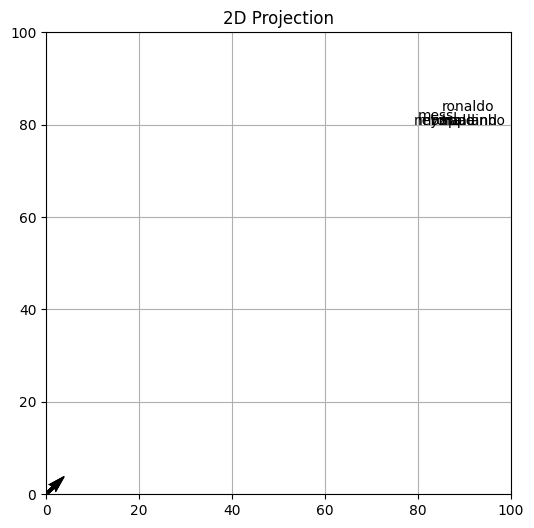

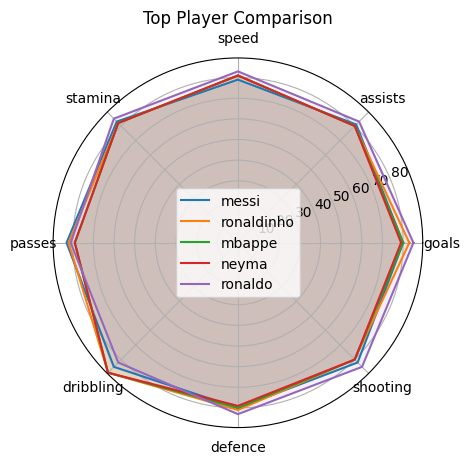

In [17]:
import numpy as np
import matplotlib.pyplot as plt

players = ["messi", "ronaldo", "neyma", "haaland", "ronaldinho", "mbappe"]
feature_names= ["goals", "assists", "speed", "stamina", "passes", "dribbling", "defence", "shooting"]
vector = np.array([
    [80, 81, 79, 83, 83, 85, 80, 82],#messi
    [85, 83, 83, 85, 81, 82, 83, 85],#ronaldo
    [79, 80, 81, 82, 79, 89, 79, 80],#neyma
     [85, 80, 81, 82, 79, 89, 79, 80],#haaland
     [83, 80, 81, 82, 82, 89, 81, 80],#ronaldinho
     [80, 80, 81, 82, 79, 89, 80, 80],#mbappe
])


#l2 norm 
def l2_norm(v):
    return np.sqrt(np.sum(v**2))

#l1 norm
def l1_norm(v):
    return np.sum(np.abs(v))

#dot product 
def dot_product(a, b):
    return np.sum(a*b)

#cosine similarity
def cosine_similarity(a, b):
    return dot_product(a, b) / (l2_norm(a) * l2_norm(b))

#normalize vector
def to_unit_vector(v):
    return v / l2_norm(v)
unit_vectors = np.array([to_unit_vector(v) for v in vector])

#Why normalization matters
#normalization removes bias from large numbers
raw_sim = cosine_similarity(vector[0], vector[1])
norm_sim = cosine_similarity(unit_vectors[0], unit_vectors[1])

print(f"raw similarity: {raw_sim}, normalize similarity: {norm_sim} ")


#rank similar players
def rank_similar(players, vector, target_idx):
    target = vector[target_idx]
    score=[]

    for i, v in enumerate(vector):
        if i == target_idx:
            continue
        sim = cosine_similarity(target, v)
        score.append((players[i], sim))
    return sorted(score, key=lambda x: x[1], reverse = True)

#testing similarity rank function
messi_idx = players.index("messi")
results = rank_similar(players, unit_vectors, messi_idx)
print("Top 3 players similar to messi")
for name, score in results[:3]:
    print(f"{name}: {score:.4f}")

#most balance player
def most_balanced(vectors):
    dim = vectors.shape[1]

    ideal = np.ones(dim)
    ideal = ideal / np.linalg.norm(ideal)

    best_idx = None
    best_score = float("inf")

    for i, v in enumerate(vectors):
        v_unit = v / np.linalg.norm(v)
        score = np.linalg.norm(v_unit - ideal)

        if score < best_score:
            best_score = score
            best_idx = i

    return best_idx, best_score


idx, score = most_balanced(vector)

print("Most balanced player:")
print(players[idx], "| score:", score)

#rader plot
def radar_chart(names, vectors, feature_names):
    num_vars = len(feature_names)
    angles = np.linspace(0, 2*np.pi, num_vars, endpoint=False)

    fig, ax = plt.subplots(subplot_kw={'polar': True})

    for name, v in zip(names, vectors):
        values = np.append(v, v[0])
        angs = np.append(angles, angles[0])

        ax.plot(angs, values, label=name)
        ax.fill(angs, values, alpha=0.1)

    ax.set_xticks(angles)
    ax.set_xticklabels(feature_names)

    plt.legend()
    plt.title("Top Player Comparison")
    plt.show()


top_names = [players[messi_idx]] + [r[0] for r in results[:4]]
top_vectors = [vector[messi_idx]] + [
    vector[players.index(r[0])] for r in results[:4]
]



#quiver plot
def quiver_plot(vectors, names):
    plt.figure(figsize=(6,6))

    for v, name in zip(vectors, names):
        plt.quiver(0, 0, v[0], v[1])
        plt.text(v[0], v[1], name)

    plt.xlim(0, 100)
    plt.ylim(0, 100)

    plt.grid()
    plt.title("2D Projection")
    plt.show()
    plt.close()


quiver_plot(vector[:6], players[:6])
radar_chart(top_names, top_vectors, feature_names)


NameError: name 'vector' is not defined